In [ ]:
#Code sample:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True)

## Toy Example(MNIST digits)

#### Build  CNN model

In [ ]:
#Toy Example(MNIST digits):

from keras import layers
from keras import models

#define model
model = models.Sequential()
#define convolutional layer
model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)))
model.add(layers.MaxPooling2D((2, 2)))
#define convolutional layer
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
#define convolutional layer
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))

#Add classfier at the top
model.add(layers.Flatten())
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(10, activation='softmax'))

#### Train model

In [ ]:
#Training the convnet on MNIST images
from keras.datasets import mnist
from keras.utils import to_categorical

(train_images, train_labels), (test_images, test_labels) = mnist.load_data()
train_images = train_images.reshape((60000, 28, 28, 1))
train_images = train_images.astype('float32') / 255

test_images = test_images.reshape((10000, 28, 28, 1))
test_images = test_images.astype('float32') / 255

train_labels = to_categorical(train_labels)
test_labels = to_categorical(test_labels)

model.compile(optimizer='rmsprop',
              loss='categorical_crossentropy',
              metrics=['accuracy'])
model.fit(train_images, train_labels, epochs=5, batch_size=64)



Instructions for updating:
Use tf.where in 2.0, which has the same broadcast rule as np.where

Epoch 1/5
60000/60000 [==============================] - 20s 327us/step - loss: 0.2730 - acc: 0.9137
Epoch 2/5
60000/60000 [==============================] - 18s 301us/step - loss: 0.0803 - acc: 0.9750
Epoch 3/5
60000/60000 [==============================] - 18s 300us/step - loss: 0.0562 - acc: 0.9825
Epoch 4/5
60000/60000 [==============================] - 18s 301us/step - loss: 0.0432 - acc: 0.9867
Epoch 5/5
60000/60000 [==============================] - 18s 303us/step - loss: 0.0349 - acc: 0.98901s - 


#### Evaluate model

In [ ]:
test_loss, test_acc = model.evaluate(test_images, test_labels)
print("accuracy:",test_acc)

10000/10000 [==============================] - 1s 111us/step
accuracy: 0.9919


# Visualization of covnets learning process

### The representations learned by convnets can be visualized using one of the methods below:
- Visualizing intermediate convnet outputs: shows how successive convnet layers transform their input
- Visualizing convnets filters : shows precisely what visual pattern or concept each filter in a convnet is receptive to
- Visualizing heatmaps of class activation in an image: shows which parts of an image were identified as belonging to a given class

### Visualizing intermediate convnet outputs (INTERMEDIATE ACTIVATIONS)
- displays the feature maps that are output by various convolution and pools layers in a network  
- allows to understand how successive convnet layers transform their input
- visualizes the feature maps with three dimensions: width, height, and depth (channels)
- each channel encodes relatively independent feature


#### Load model

In [ ]:
from keras import models
from keras.models import load_model

#load model from file (we don't create model from scratch)
model = load_model('cats_and_dogs.h5')
model.summary()

#Save model diagram in file
from keras.utils import plot_model
plot_model(model, to_file='model.png')

#Show diagram
print("\nShow diagram:")
import matplotlib.image as mpimg
import matplotlib.pyplot as plt
img= mpimg.imread('model.png')
plt.imshow(img)

Using TensorFlow backend.







Instructions for updating:
Please use `rate` instead of `keep_prob`. Rate should be set to `rate = 1 - keep_prob`.


Instructions for updating:
Use tf.where in 2.0, which has the same broadcast rule as np.where
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d_21 (Conv2D)           (None, 148, 148, 32)      896       
_________________________________________________________________
max_pooling2d_21 (MaxPooling (None, 74, 74, 32)        0         
_________________________________________________________________
conv2d_22 (Conv2D)           (None, 72, 72, 64)        18496     
_________________________________________________________________
max_pooling2d_22 (MaxPooling (None, 36, 36, 64)        0         
_________________________________________________________________
conv2d_23 (Conv2D)           (None, 34, 34, 128)       73856     
__________________________________________________________

#### Load image

Tensor shape: (1, 150, 150, 3)


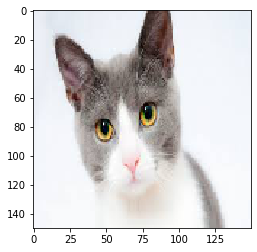

In [ ]:
#load image
img_path = 'cat2.png'
from keras.preprocessing import image
import numpy as np
img = image.load_img(img_path, target_size=(150, 150))
img_tensor = image.img_to_array(img)
img_tensor = np.expand_dims(img_tensor, axis=0)
img_tensor /= 255.

print("Tensor shape:",img_tensor.shape)

#Show image
import matplotlib.pyplot as plt
plt.imshow(img_tensor[0])
plt.show()

#### Visualize 4th and 7th channel

In [ ]:
from keras import models
layer_outputs = [layer.output for layer in model.layers[:8]]
activation_model = models.Model(inputs=model.input, outputs=layer_outputs)

activations = activation_model.predict(img_tensor)
first_layer_activation = activations[0]


In my case the forth channel detects diagonal edges.
But your result can differ while specific filters learned by CNN are not deterministic.


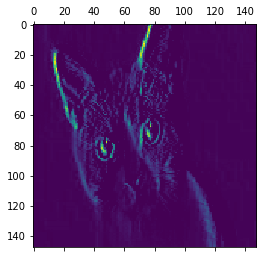

In [ ]:
#Visualizing the fourth channel
import matplotlib.pyplot as plt
plt.matshow(first_layer_activation[0, :, :, 4], cmap='viridis')
print("\nIn my case the forth channel detects diagonal edges.\nBut your result can differ while specific filters learned by CNN are not deterministic.")

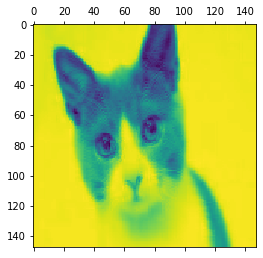

In [ ]:
# Seventh channel of the activation of the first layer on the test cat
plt.matshow(first_layer_activation[0, :, :, 7], cmap='viridis')

#### Visualize every channel

C:\Users\Robert\Anaconda3\lib\site-packages\ipykernel_launcher.py:23: RuntimeWarning: invalid value encountered in true_divide


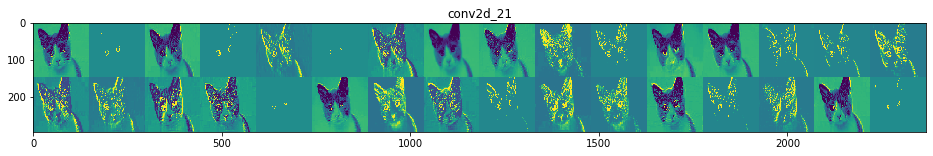

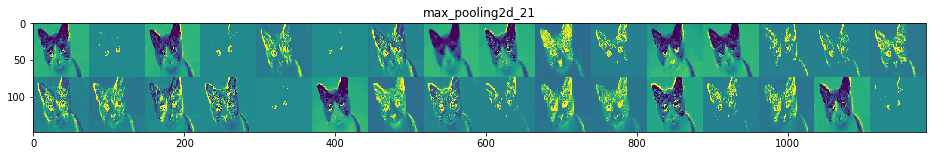

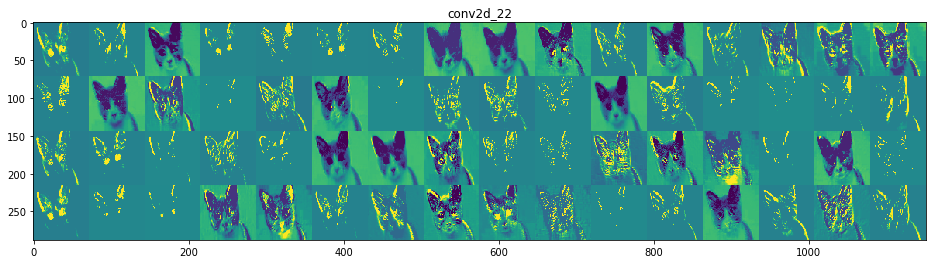

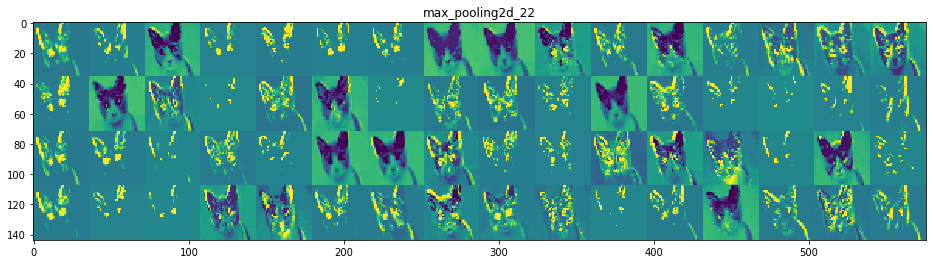

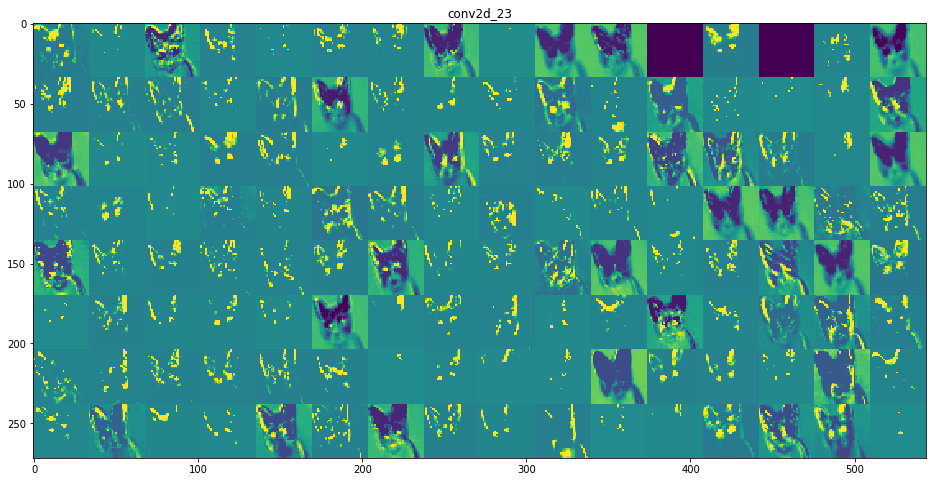

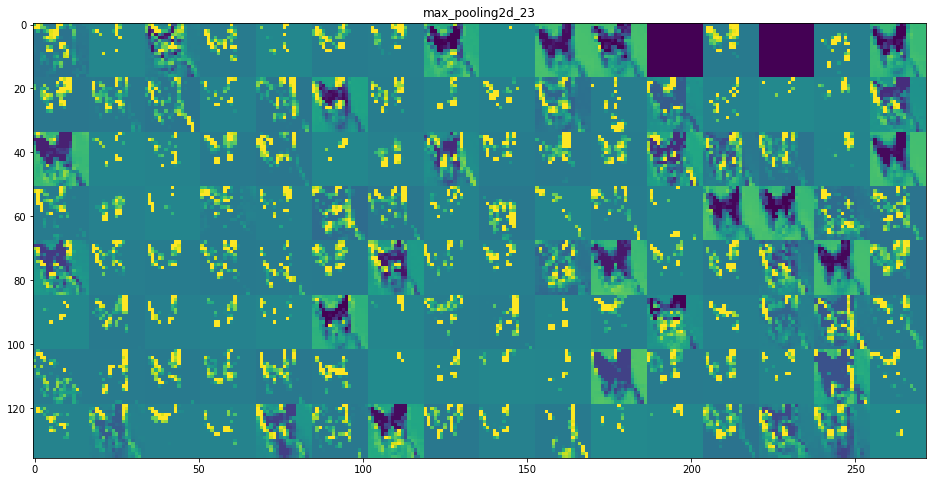

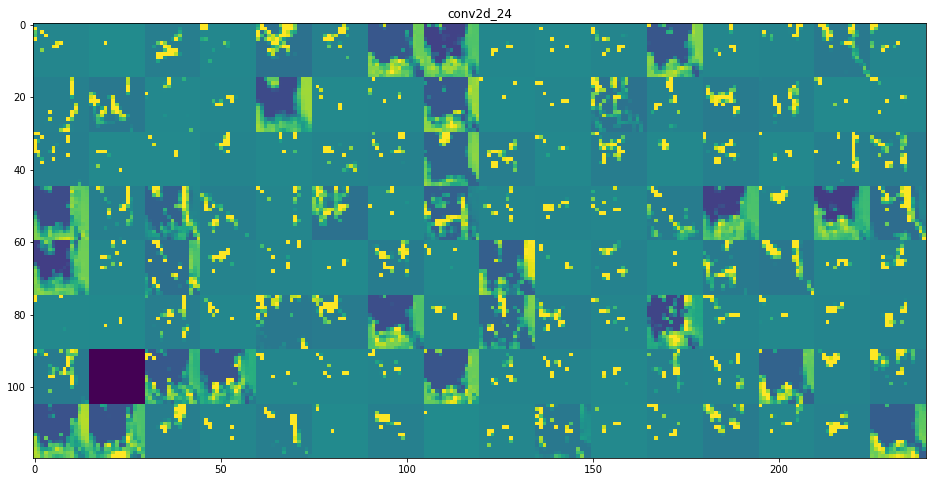

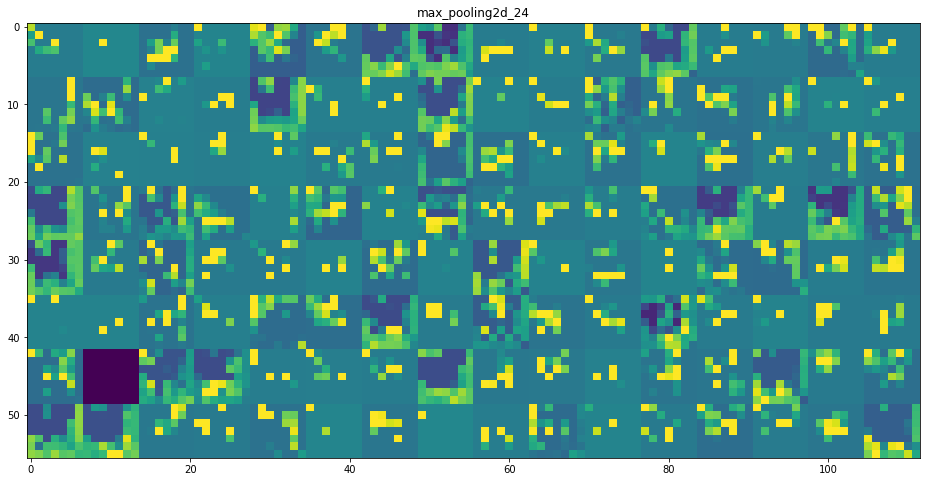

In [ ]:
#Visualizing every channel in every intermediate activation

layer_names = []
for layer in model.layers[:8]:
    layer_names.append(layer.name)

images_per_row = 16

for layer_name, layer_activation in zip(layer_names, activations):
    n_features = layer_activation.shape[-1]

    size = layer_activation.shape[1]

    n_cols = n_features // images_per_row
    display_grid = np.zeros((size * n_cols, images_per_row * size))

    for col in range(n_cols):
        for row in range(images_per_row):
            channel_image = layer_activation[0,
                                             :, :,
                                             col * images_per_row + row]
            channel_image -= channel_image.mean()
            channel_image /= channel_image.std()
            channel_image *= 64
            channel_image += 128
            channel_image = np.clip(channel_image, 0, 255).astype('uint8')
            display_grid[col * size : (col + 1) * size,
                         row * size : (row + 1) * size] = channel_image

    scale = 1. / size
    plt.figure(figsize=(scale * display_grid.shape[1],
                        scale * display_grid.shape[0]))
    plt.title(layer_name)
    plt.grid(False)
    plt.imshow(display_grid, aspect='auto', cmap='viridis')

#### Summary
- the first layer acts as a collection of various edge detectors. The activations retain almost all of the information present in the initial picture
- the higher activations layers become increasingly abstract and less visually interpretable
- in the following layers, more and more filters are blank
- blank square means the pattern encoded by the filter isn’t found in the input image
- specific filters learned by convolution layers aren’t deterministic

In [ ]:
#load VGG16 model
from keras.applications.vgg16 import VGG16
model = VGG16(weights='imagenet')

from keras.preprocessing import image
from keras.applications.vgg16 import preprocess_input, decode_predictions
import numpy as np
import matplotlib.pyplot as plt

#### Load image and make prediction

In [ ]:
#load image
img_path = 'elephant1.png'
img = image.load_img(img_path, target_size=(224, 224))

#createfloat32 Numpy array of shape (224, 224, 3)
x = image.img_to_array(img)

#Adds a dimension to transform the array into a batch of size
x = np.expand_dims(x, axis=0)
x = preprocess_input(x)

#make prediction for selected image
preds = model.predict(x)
print('most probably 3 classes:\n', decode_predictions(preds, top=3)[0])
# 386 is the number of the african elephant class
print('predicted class number:\n',np.argmax(preds[0]))

most probably 3 classes:
 [('n02504458', 'African_elephant', 0.88880086), ('n01871265', 'tusker', 0.10223417), ('n02504013', 'Indian_elephant', 0.008635206)]
predicted class number:
 386


#### Create heatmap

In [ ]:
from keras import backend as K

# Get "African elephant” entry from the prediction vector
african_elephant_output = model.output[:, 386]

#Output feature map of the block5_conv3 layer,the last convolutional layer in VGG16
last_conv_layer = model.get_layer('block5_conv3')

#Gradient of the “African elephant” class with regard to the output feature map of block5_conv3
grads = K.gradients(african_elephant_output, last_conv_layer.output)[0]

#Vector of shape (512,), where each entry is the mean intensity of the gradient over a specific feature-map
pooled_grads = K.mean(grads, axis=(0, 1, 2))
print("pooled_grads:\n",pooled_grads)

#returns function which evaluates outputs([pooled_grads, last_conv_layer.output[0]]) using inputs
iterate = K.function([model.input],[pooled_grads, last_conv_layer.output[0]])
#Get two Numpy arrays for image X
pooled_grads_value, conv_layer_output_value = iterate([x])

#Multiply each channel in the feature-map array by importance of the channel
for i in range(512):
    conv_layer_output_value[:, :, i] *= pooled_grads_value[i]

#The channel-wise mean of the resulting feature map is the heatmap of the class activation.
heatmap = np.mean(conv_layer_output_value, axis=-1)

pooled_grads:
 Tensor("Mean_1:0", shape=(512,), dtype=float32)


#### Normalize heatmap

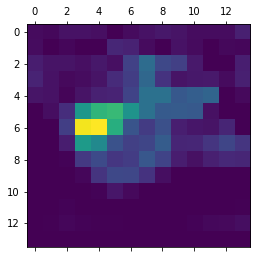

In [ ]:
#Normalize values between 0 and 1
heatmap = np.maximum(heatmap, 0)
heatmap /= np.max(heatmap)
#Show heatmap
plt.matshow(heatmap)

#### Join the heatmap and original  image


The most informative area of the image is the head of small elephant.


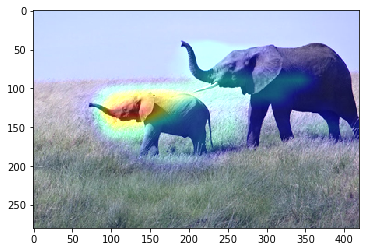

In [ ]:
#install cv2 (opencv) is neccessary
#!pip install opencv-python
import cv2
import matplotlib.image as mpimg
img_name='elephant_heatmap.png'

img = cv2.imread(img_path)
heatmap2 = cv2.resize(heatmap, (img.shape[1], img.shape[0]))

#Converts the heatmap to RGB
heatmap2 = np.uint8(255 * heatmap2)
#Create colorMap using heatmap,higher value mean more reddishcolor
heatmap2 = cv2.applyColorMap(heatmap2, cv2.COLORMAP_JET)

#join heatmap and image
superimposed_img = heatmap2 * 0.4 + img
cv2.imwrite(img_name, superimposed_img)

#show image
img= mpimg.imread(img_name)
plt.imshow(img)
print("\nThe most informative area of the image is the head of small elephant.")

#### Summary
- heatmap methods explains why African elephant was found in the image
- finds the location of African elephant on the image

In [ ]:
#Embedding layer takes at least two arguments: the number of possible tokens
#(here, 1,000: 1 + maximum word index) and the dimensionality of the embeddings (here, 64).
from keras.layers import Embedding

embedding_layer = Embedding(1000, 64)